# Rekomendasi K-Drama Berdasarkan Genre

> Notebook ini berisi program sederhana untuk memberikan rekomendasi K-Drama berdasarkan genre yang dipilih pengguna.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Muat dataset
data = pd.read_csv('/content/drive/MyDrive/sistem_rekom/kdrama.csv')

print('Jumlah data review :', len(data))

Jumlah data review : 250


# Data Understanding

In [ ]:
# Ukuran dan struktur data
print("Jumlah data:", data.shape)
data.info()

Jumlah data: (250, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  250 non-null    object 
 1   Aired Date            250 non-null    object 
 2   Year of release       250 non-null    int64  
 3   Original Network      250 non-null    object 
 4   Aired On              250 non-null    object 
 5   Number of Episodes    250 non-null    int64  
 6   Duration              250 non-null    object 
 7   Content Rating        245 non-null    object 
 8   Rating                250 non-null    float64
 9   Synopsis              250 non-null    object 
 10  Genre                 250 non-null    object 
 11  Tags                  250 non-null    object 
 12  Director              249 non-null    object 
 13  Screenwriter          249 non-null    object 
 14  Cast                  250 non-null    object 
 15  

- **Jumlah data:** 250 baris dan 17 kolom.

- **Tipe Data:**
  - Terdapat **14 kolom** bertipe **object**. Biasanya ini adalah fitur kategoris atau teks. Kolom-kolom tersebut adalah:
    - Name
    - Aired Date
    - Original Network
    - Aired On
    - Duration
    - Content Rating
    - Synopsis
    - Genre
    - Tags
    - Director
    - Screenwriter
    - Cast
    - Production companies
    - Rank
  - Terdapat **2 kolom** bertipe **int64**, yang merupakan data numerik:
    - Year of release
    - Number of Episodes
  - Terdapat **1 kolom** bertipe **float64**:
    - Rating

In [ ]:
data.head()

,Name,Aired Date,Year of release,Original Network,Aired On,Number of Episodes,Duration,Content Rating,Rating,Synopsis,Genre,Tags,Director,Screenwriter,Cast,Production companies,Rank
0,Move to Heaven,"May 14, 2021",2021,Netflix,Friday,10,52 min.,18+ Restricted (violence & profanity),9.2,Geu Roo is a young autistic man. He works for ...,"Life, Drama, Family","Autism, Uncle-Nephew Relationship, Death, Sava...",Kim Sung Ho,Yoon Ji Ryun,"Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju...","Page One Film, Number Three Pictures",#1
1,Flower of Evil,"Jul 29, 2020 - Sep 23, 2020",2020,tvN,"Wednesday, Thursday",16,1 hr. 10 min.,15+ - Teens 15 or older,9.1,Although Baek Hee Sung is hiding a dark secret...,"Thriller, Romance, Crime, Melodrama","Married Couple, Deception, Suspense, Family Se...","Kim Chul Gyu, Yoon Jong Ho",Yoo Jung Hee,"Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ...",Monster Union,#2
2,Hospital Playlist,"Mar 12, 2020 - May 28, 2020",2020,"Netflix, tvN",Thursday,12,1 hr. 30 min.,15+ - Teens 15 or older,9.1,The stories of people going through their days...,"Friendship, Romance, Life, Medical","Strong Friendship, Multiple Mains, Best Friend...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#3
3,Hospital Playlist 2,"Jun 17, 2021 - Sep 16, 2021",2021,"Netflix, tvN",Thursday,12,1 hr. 40 min.,15+ - Teens 15 or older,9.1,Everyday is extraordinary for five doctors and...,"Friendship, Romance, Life, Medical","Workplace, Strong Friendship, Best Friends, Mu...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#4
4,My Mister,"Mar 21, 2018 - May 17, 2018",2018,tvN,"Wednesday, Thursday",16,1 hr. 17 min.,15+ - Teens 15 or older,9.1,Park Dong Hoon is a middle-aged engineer who i...,"Psychological, Life, Drama, Family","Age Gap, Nice Male Lead, Strong Female Lead, H...","Kim Won Suk, Kim Sang Woo",Park Hae Young,"Lee Sun Kyun, IU, Park Ho San, Song Sae Byuk, ...",Chorokbaem Media,#5


In [ ]:
print(f'Pada Dataset Terdapat {data.shape[0]} Table dan {data.shape[1]} columns.')

Pada Dataset Terdapat 250 Table dan 17 columns.


In [ ]:
for i, (nama_kolom, jumlah) in enumerate(data.count().items(), 1):
    print(f"Kolom {i:2d}: {nama_kolom} → Berjumlah : {jumlah}")

Kolom  1: Name → Berjumlah : 250
Kolom  2: Aired Date → Berjumlah : 250
Kolom  3: Year of release → Berjumlah : 250
Kolom  4: Original Network → Berjumlah : 250
Kolom  5: Aired On → Berjumlah : 250
Kolom  6: Number of Episodes → Berjumlah : 250
Kolom  7: Duration → Berjumlah : 250
Kolom  8: Content Rating → Berjumlah : 245
Kolom  9: Rating → Berjumlah : 250
Kolom 10: Synopsis → Berjumlah : 250
Kolom 11: Genre → Berjumlah : 250
Kolom 12: Tags → Berjumlah : 250
Kolom 13: Director → Berjumlah : 249
Kolom 14: Screenwriter → Berjumlah : 249
Kolom 15: Cast → Berjumlah : 250
Kolom 16: Production companies → Berjumlah : 248
Kolom 17: Rank → Berjumlah : 250


In [ ]:
#mengecek data apakah terdapat data yang duplikat

data.duplicated().sum()
print(f'Jumlah data duplikat : {data.duplicated().sum()}')

Jumlah data duplikat : 0


In [ ]:
# mengecek data apakah ada missing value

data.isnull().sum()

,0
Name,0
Aired Date,0
Year of release,0
Original Network,0
Aired On,0
Number of Episodes,0
Duration,0
Content Rating,5
Rating,0
Synopsis,0


terdapat missing value pada kolom Content Rating, Director, Screenwriter, dan Production companies

In [ ]:
# ternyata dataset ini ada missing value sehingga dilakukan penghapusan missing value

data = data.dropna()

In [ ]:
# cek kembali missing value apakah masih ada

data.isnull().sum()

,0
Name,0
Aired Date,0
Year of release,0
Original Network,0
Aired On,0
Number of Episodes,0
Duration,0
Content Rating,0
Rating,0
Synopsis,0


missing value sudah teratasi

# Exploratory Data Analysis (EDA)

In [ ]:
data.columns

Index(['Name', 'Aired Date', 'Year of release', 'Original Network', 'Aired On',
       'Number of Episodes', 'Duration', 'Content Rating', 'Rating',
       'Synopsis', 'Genre', 'Tags', 'Director', 'Screenwriter', 'Cast',
       'Production companies', 'Rank'],
      dtype='object')

Kolom datasets anime memiliki informasi berikut:

*    Name : Judul KDrama
*    Aired Date : Tanggal dari saat hingga KDrama pertama kali ditayangkan.
*    Year of release : Tahun rilis KDrama
*    Original Network : Penayangan KDrama
*    Aired On : Hari-hari dalam seminggu saat KDrama ditayangkan.
*    Number of Episodes : Jumlah episode yang ada
*    Duration : Lama penayangan (dalam jam dan menit)
*    Content Rating : Batasan usia
*    Rating : Skor atau penilaian yang diberikan penonton pada KDrama
*    Sypnosis : Sipnosis dari KDrama
*    Genre : Jenis KDrama (Life, Drama, Romantic, dan lainnya)
*    Tags : Tema
*    Director : Sutradara
*    Screenwriter : Pnulis
*    Cast : Pemeran
*    Production companies : Perusahaan yang memproduksi KDrama
*    Rank : Peringkat KDrama

# Visualization

<ipython-input-12-fc341ec3a432>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Rating', palette='pastel')


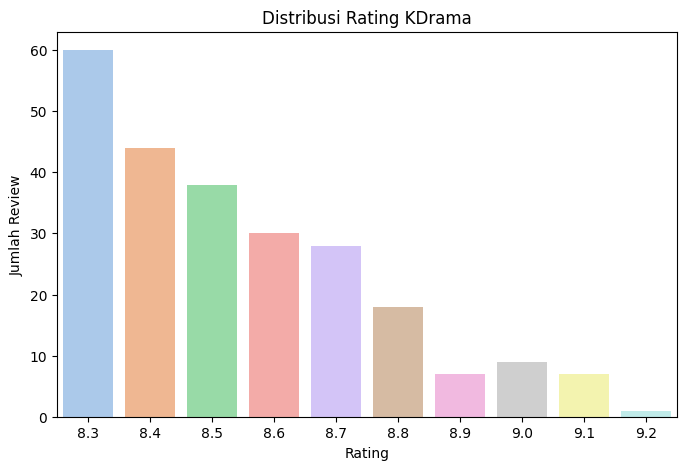

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Rating', palette='pastel')
plt.title("Distribusi Rating KDrama")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()


menunjukkan distribusi rating yang ada pada dataset KDrama

<ipython-input-13-a16c12f8876f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_names.values, y=top_names.index, palette='Set2')


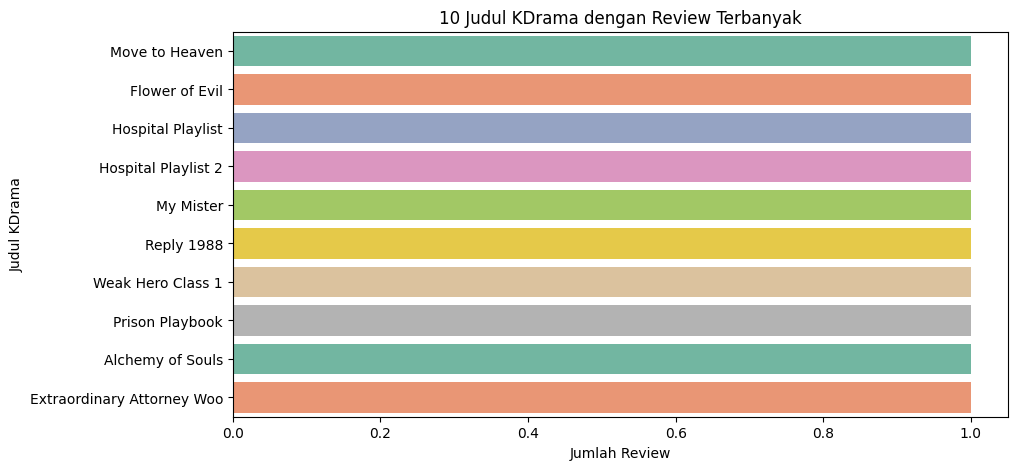

In [ ]:
# Judul terpopuler berdasarkan jumlah review
top_names = data['Name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_names.values, y=top_names.index, palette='Set2')
plt.title("10 Judul KDrama dengan Review Terbanyak")
plt.xlabel("Jumlah Review")
plt.ylabel("Judul KDrama")
plt.show()

didapatkan 10 teratas judul KDrama yang paling banyak di review oleh penonton

<ipython-input-14-53b8aa6e807a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')


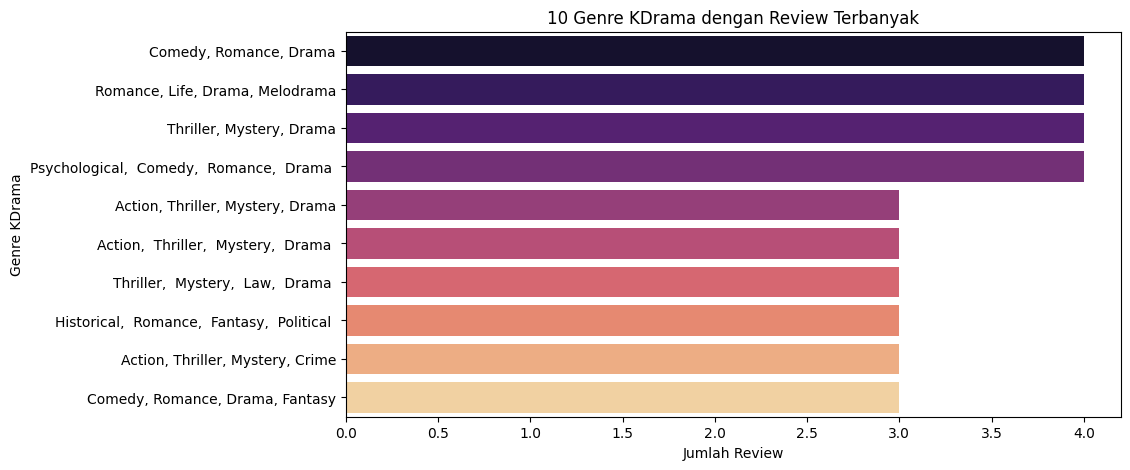

In [ ]:
# 10 Genre dengan Review Terbanyak
top_genres = data['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title("10 Genre KDrama dengan Review Terbanyak")
plt.xlabel("Jumlah Review")
plt.ylabel("Genre KDrama")
plt.show()

didapatkan 10 genre yang telah banyak di review oleh penonton

<ipython-input-15-2880b1c5e23e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rated['Rating'], y=top_rated.index, palette='Blues_d')
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


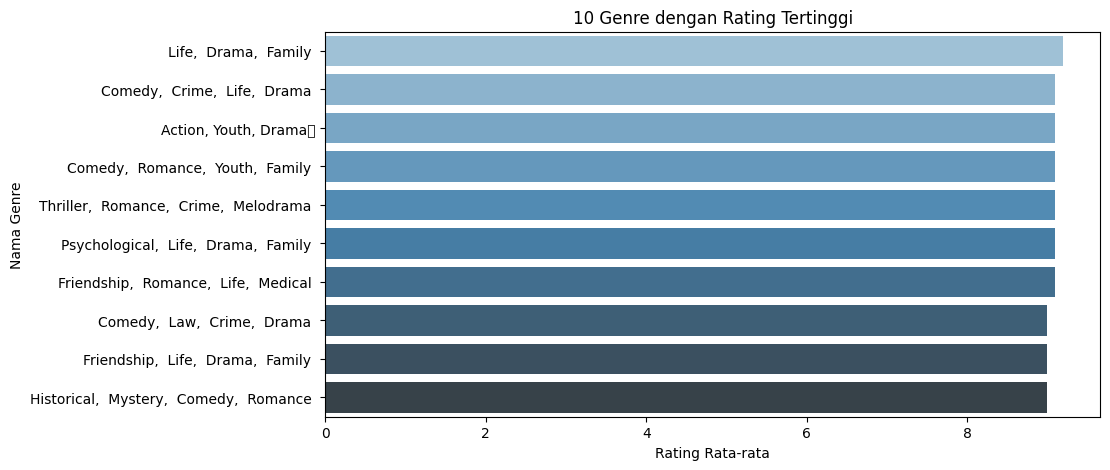

In [ ]:
# Genre dengan rating tertinggi
top_rated = data[['Genre', 'Rating']].groupby('Genre').mean().sort_values('Rating', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_rated['Rating'], y=top_rated.index, palette='Blues_d')
plt.title("10 Genre dengan Rating Tertinggi")
plt.xlabel("Rating Rata-rata")
plt.ylabel("Nama Genre")
plt.show()

didapatkan 10 genre dengan rating tertinggi

<ipython-input-16-ca4f2ed213cb>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_rating_top_names.values, y=mean_rating_top_names.index, palette='crest')


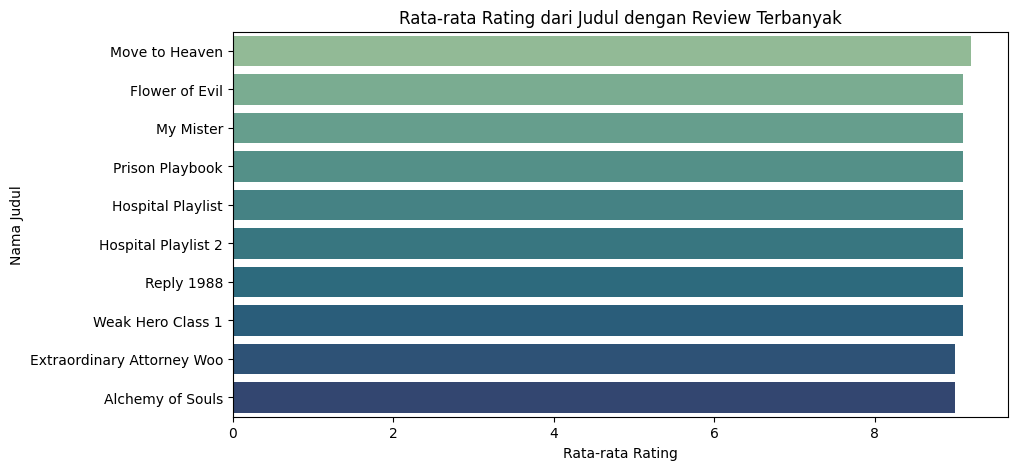

In [ ]:
# Judul dengan jumlah review terbanyak
top_names = data['Name'].value_counts().head(10).index

# Rata-rata rating judul tersebut
mean_rating_top_names = data[data['Name'].isin(top_names)].groupby('Name')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=mean_rating_top_names.values, y=mean_rating_top_names.index, palette='crest')
plt.title("Rata-rata Rating dari Judul dengan Review Terbanyak")
plt.xlabel("Rata-rata Rating")
plt.ylabel("Nama Judul")
plt.show()

didapatkan rata rata rating dari judul dengan review terbanyak

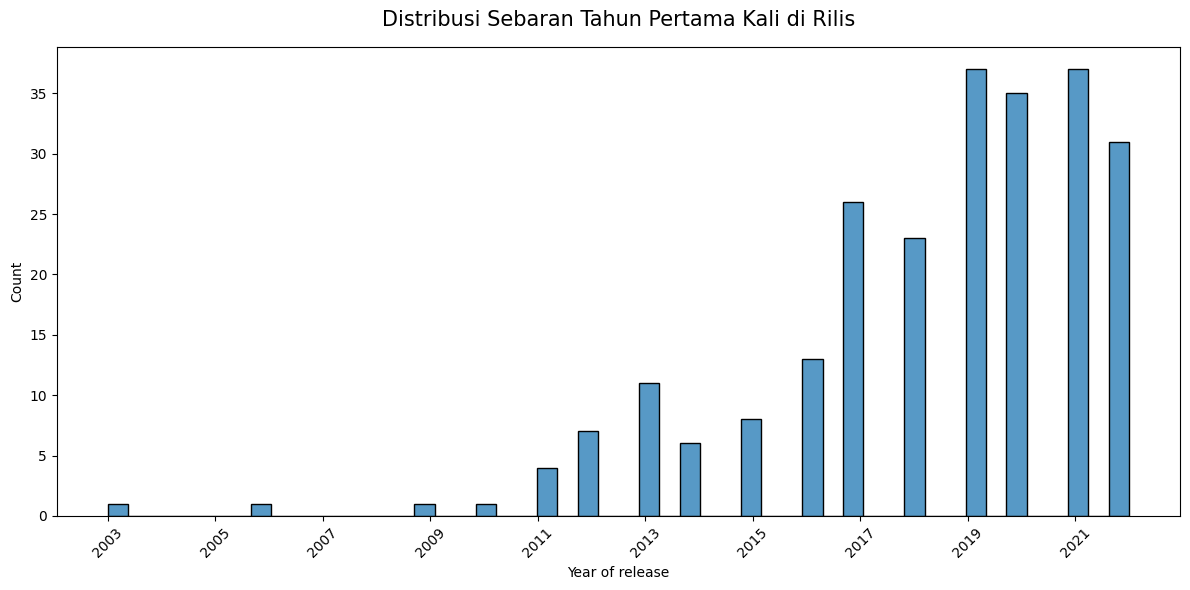

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Bersihkan data
data = data.dropna(subset=['Year of release'])
data['Year of release'] = data['Year of release'].astype(int)

# Plot histogram
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='Year of release', bins=50)
plt.title('Distribusi Sebaran Tahun Pertama Kali di Rilis', fontsize=15, pad=15)

# Atur ticks di sumbu X agar hanya tampil tahun bulat
min_year = data['Year of release'].min()
max_year = data['Year of release'].max()
plt.xticks(np.arange(min_year, max_year + 1, step=2), rotation=45)

plt.tight_layout()
plt.show()

dilakukan visualisasi persebaran tahun pertama ketika rilis dari masing-masing judul KDrama

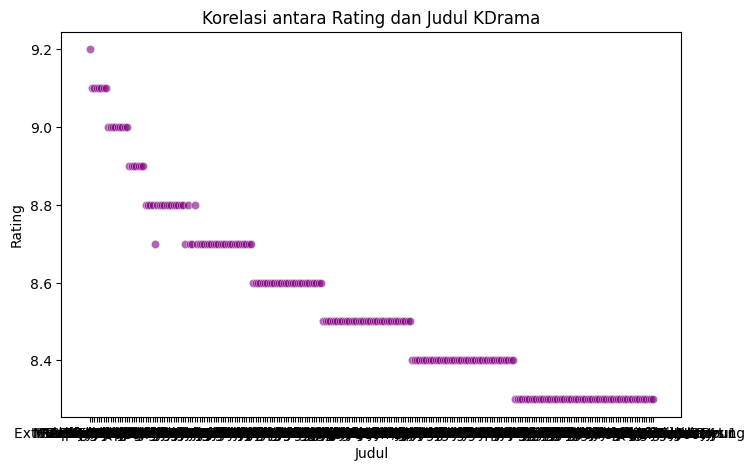

In [ ]:
# Korelasi antara Rating dan Judul
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Name', y='Rating', alpha=0.6, color='purple')
plt.title("Korelasi antara Rating dan Judul KDrama")
plt.xlabel("Judul")
plt.ylabel("Rating")
plt.show()

scatterplot diatas menunjukkan korelasi antara rating dan judul

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


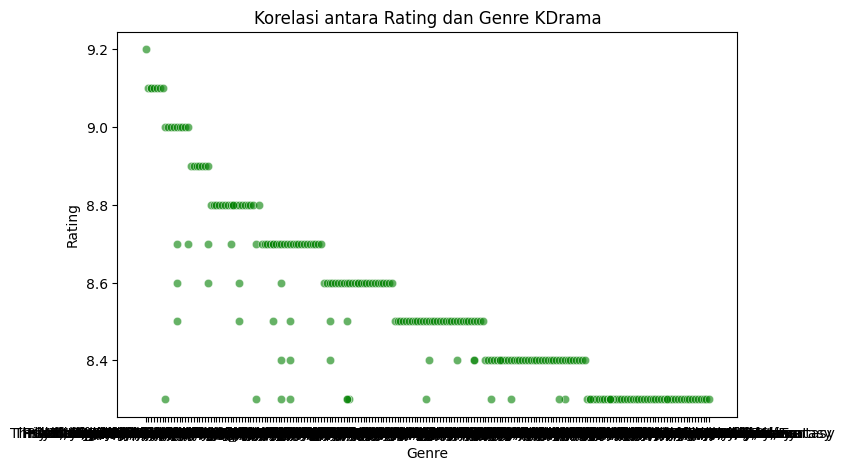

In [ ]:
# Korelasi antara Rating dan Genre
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Genre', y='Rating', alpha=0.6, color='green')
plt.title("Korelasi antara Rating dan Genre KDrama")
plt.xlabel("Genre")
plt.ylabel("Rating")
plt.show()

scatterplot diatas menunjukkan korelasi antara rating dan genre

# Data Preparation

In [ ]:
import re

# melakukan penghapusan link pada judul KDrama
def text_cleaning(text):
  text = re.sub(r"[^\w\s]", "", text)
  text = re.sub(r"https?://[^\s]+", "", text)
  return text

data['Name'] = data['Name'].apply(text_cleaning)

In [ ]:
# dilakukan pengecekan ulang pada data yang duplikat

data.duplicated().sum()
print(f'Jumlah data duplikat : {data.duplicated().sum()}')

Jumlah data duplikat : 0


In [ ]:
# dilakukan pengecekan ulang pada data yang memiliki missing value

data.isnull().sum()

,0
Name,0
Aired Date,0
Year of release,0
Original Network,0
Aired On,0
Number of Episodes,0
Duration,0
Content Rating,0
Rating,0
Synopsis,0


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year of release,242.0,2018.301653,3.199442,2003.0,2017.0,2019.0,2021.0,2022.0
Number of Episodes,242.0,19.297521,13.369405,4.0,16.0,16.0,20.0,133.0
Rating,242.0,8.540496,0.221866,8.3,8.4,8.5,8.7,9.2


Fungsi `describe()` menampilkan statistik ringkasan untuk setiap kolom, seperti jumlah data (count), rata-rata (mean), standar deviasi (std), nilai minimum (min), kuartil (25%, 50%, 75%), dan nilai maksimum (max).


# Model Development

In [ ]:
data

,Name,Aired Date,Year of release,Original Network,Aired On,Number of Episodes,Duration,Content Rating,Rating,Synopsis,Genre,Tags,Director,Screenwriter,Cast,Production companies,Rank
0,Move to Heaven,"May 14, 2021",2021,Netflix,Friday,10,52 min.,18+ Restricted (violence & profanity),9.2,Geu Roo is a young autistic man. He works for ...,"Life, Drama, Family","Autism, Uncle-Nephew Relationship, Death, Sava...",Kim Sung Ho,Yoon Ji Ryun,"Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju...","Page One Film, Number Three Pictures",#1
1,Flower of Evil,"Jul 29, 2020 - Sep 23, 2020",2020,tvN,"Wednesday, Thursday",16,1 hr. 10 min.,15+ - Teens 15 or older,9.1,Although Baek Hee Sung is hiding a dark secret...,"Thriller, Romance, Crime, Melodrama","Married Couple, Deception, Suspense, Family Se...","Kim Chul Gyu, Yoon Jong Ho",Yoo Jung Hee,"Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ...",Monster Union,#2
2,Hospital Playlist,"Mar 12, 2020 - May 28, 2020",2020,"Netflix, tvN",Thursday,12,1 hr. 30 min.,15+ - Teens 15 or older,9.1,The stories of people going through their days...,"Friendship, Romance, Life, Medical","Strong Friendship, Multiple Mains, Best Friend...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#3
3,Hospital Playlist 2,"Jun 17, 2021 - Sep 16, 2021",2021,"Netflix, tvN",Thursday,12,1 hr. 40 min.,15+ - Teens 15 or older,9.1,Everyday is extraordinary for five doctors and...,"Friendship, Romance, Life, Medical","Workplace, Strong Friendship, Best Friends, Mu...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#4
4,My Mister,"Mar 21, 2018 - May 17, 2018",2018,tvN,"Wednesday, Thursday",16,1 hr. 17 min.,15+ - Teens 15 or older,9.1,Park Dong Hoon is a middle-aged engineer who i...,"Psychological, Life, Drama, Family","Age Gap, Nice Male Lead, Strong Female Lead, H...","Kim Won Suk, Kim Sang Woo",Park Hae Young,"Lee Sun Kyun, IU, Park Ho San, Song Sae Byuk, ...",Chorokbaem Media,#5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Live Up to Your Name,"Aug 12, 2017 - Oct 1, 2017",2017,tvN,"Saturday, Sunday",16,1 hr. 10 min.,15+ - Teens 15 or older,8.3,"Heo Im, who is born in a concubine family in t...","Historical, Romance, Medical, Fantasy","Time Travel, Joseon Dynasty, Acupuncture, Stro...",Hong Jong Chan,Kim Eun Hee,"Kim Nam Gil, Kim Ah Joong, Yoo Min Kyu, Moon G...",Bon Factory Worldwide,#246
246,Queen for Seven Days,"May 31, 2017 - Aug 3, 2017",2017,KBS2,"Wednesday, Thursday",20,60 min.,15+ - Teens 15 or older,8.3,This drama is about the love story between Kin...,"Historical, Romance, Melodrama, Political","Joseon Dynasty, Sibling Rivalry, Lying, Reveng...",Lee Jung Sub,Choi Jin Young,"Park Min Young, Yeon Woo Jin, Lee Dong Gun, Ja...","Monster Union, OH!BROTHERS Production",#247
247,Memory,"Mar 18, 2016 - May 7, 2016",2016,tvN,"Friday, Saturday",16,1 hr. 5 min.,15+ - Teens 15 or older,8.3,Park Tae Suk is a lawyer who finds out that he...,"Law, Romance, Life, Drama","Alzheimer's Disease, Teamwork, Bromance, Mothe...",Park Chan Hong,Kim Ji Woo,"Lee Sung Min, Kim Jee Soo, Park Jin Hee, Lee J...",MI Inc.,#248
248,A Korean Odyssey,"Dec 23, 2017 - Mar 4, 2018",2017,"Netflix, tvN","Saturday, Sunday",20,1 hr. 20 min.,15+ - Teens 15 or older,8.3,"In 2017, Son Oh Gong and Ma Wang are in confli...","Horror, Comedy, Romance, Fantasy","Ghost-seeing Female Lead, Special Power, Super...","Park Hong Kyun, Kim Jung Hyun, Kim Byung Soo","Hong Jung Eun, Hong Mi Ran","Lee Seung Gi, Cha Seung Won, Oh Yeon Seo, Lee ...",JS Pictures,#249


In [ ]:
data = data.drop(columns=[
    'Aired Date',
    'Year of release',
    'Aired On',
    'Number of Episodes',
    'Duration',
    'Content Rating',
    'Synopsis',
    'Tags',
    'Director',
    'Screenwriter',
    'Cast',
    'Rank'
])


Melakukan penghapusan pada kolom yang tidak dibutuhkan

In [ ]:
data

,Name,Original Network,Rating,Genre,Production companies
0,Move to Heaven,Netflix,9.2,"Life, Drama, Family","Page One Film, Number Three Pictures"
1,Flower of Evil,tvN,9.1,"Thriller, Romance, Crime, Melodrama",Monster Union
2,Hospital Playlist,"Netflix, tvN",9.1,"Friendship, Romance, Life, Medical","Egg Is Coming, CJ ENM"
3,Hospital Playlist 2,"Netflix, tvN",9.1,"Friendship, Romance, Life, Medical","Egg Is Coming, CJ ENM"
4,My Mister,tvN,9.1,"Psychological, Life, Drama, Family",Chorokbaem Media
...,...,...,...,...,...
245,Live Up to Your Name,tvN,8.3,"Historical, Romance, Medical, Fantasy",Bon Factory Worldwide
246,Queen for Seven Days,KBS2,8.3,"Historical, Romance, Melodrama, Political","Monster Union, OH!BROTHERS Production"
247,Memory,tvN,8.3,"Law, Romance, Life, Drama",MI Inc.
248,A Korean Odyssey,"Netflix, tvN",8.3,"Horror, Comedy, Romance, Fantasy",JS Pictures


# Model Content Based Filtering (menggunakan kdrama_recommendations)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Buat TF-IDF Vectorizer dan fit data pada 'Genre'
tfid = TfidfVectorizer()
tfid_matrix = tfid.fit_transform(data['Genre'])  # Gunakan Genre sebagai fitur

In [ ]:
tfidf_matrix = tfid.fit_transform(data['Genre'])

tfidf_matrix.shape

(242, 30)

In [ ]:
pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfid.get_feature_names_out(),
    index=data.Genre
).sample(22, axis=1).sample(10, axis=0)

,sitcom,music,school,medical,sci,fi,horror,crime,youth,comedy,...,life,political,military,family,food,friendship,sports,mystery,action,historical
Genre,,,,,,,,,,,,,,,,,,,,,
"Thriller, Mystery, Law, Drama",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.438932,0.000000,0.000000
"Business, Comedy, Romance, Sports",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.307465,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.677946,0.000000,0.000000,0.000000
"Action, Thriller, Comedy, Romance, Drama, Supernatural",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.364817,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.475232,0.000000
"Horror, Comedy, Romance, Supernatural",0.0,0.0,0.0,0.0,0.000000,0.000000,0.697104,0.0,0.0,0.351048,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
"Law, Romance, Life, Drama",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.564071,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
"Action, Thriller, Horror, Sci-Fi",0.0,0.0,0.0,0.0,0.521009,0.521009,0.521009,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.341778,0.000000
"Thriller, Mystery, Drama",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.608255,0.000000,0.000000
"Comedy, Romance, Drama",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.669241,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
"Historical, Romance, Melodrama, Political",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.635472,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.526073


Matriks ini menunjukkan korelasi antara KDrama terhadap kategori yang dipilih.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1.        , 0.        , 0.2306812 , ..., 0.42872005, 0.        ,
        0.        ],
       [0.        , 1.        , 0.07879818, ..., 0.10609312, 0.08910993,
        0.57648491],
       [0.2306812 , 0.07879818, 1.        , ..., 0.31810656, 0.06869611,
        0.        ],
       ...,
       [0.42872005, 0.10609312, 0.31810656, ..., 1.        , 0.09249177,
        0.        ],
       [0.        , 0.08910993, 0.06869611, ..., 0.09249177, 1.        ,
        0.        ],
       [0.        , 0.57648491, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [ ]:
cosine_sim_df = pd.DataFrame(cosine_sim, index=data['Name'], columns=data['Name'])
print('Shape:', cosine_sim_df.shape)

# Melihat similarity matrix
cosine_sim_df.sample(5, axis=1).sample(5, axis=0)

Shape: (242, 242)


Name,Once Again,100 Days My Prince,The Masters Sun,Beyond Evil,Seasons of Blossom
Name,,,,,
My Mister,0.569127,0.106870,0.000000,0.522224,0.095100
Military Prosecutor Doberman,0.000000,0.000000,0.000000,0.125280,0.000000
Chicago Typewriter,0.253722,0.287897,0.548303,0.000000,0.256190
All of Us Are Dead,0.000000,0.000000,0.363197,0.111143,0.000000
The Crowned Clown,0.092587,0.468060,0.076138,0.000000,0.093487


In [ ]:
def kdrama_recommendations(kdrama_name, similarity_data=cosine_sim_df, items=data[['Name','Genre']], k=5):

    index = similarity_data.loc[:,kdrama_name].to_numpy().argpartition(
        range(-1, -k, -1))

    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    closest = closest.drop(kdrama_name, errors='ignore')

    return pd.DataFrame(closest).merge(items).head(k)

In [ ]:
data[data.Name.eq('Memory')]

,Name,Original Network,Rating,Genre,Production companies
247,Memory,tvN,8.3,"Law, Romance, Life, Drama",MI Inc.


In [ ]:
kdrama_recommendations('Memory')

,Name,Genre
0,Extraordinary Attorney Woo,"Law, Romance, Life, Drama"
1,Oh My Venus,"Comedy, Law, Romance, Life"
2,Juvenile Justice,"Law, Drama"
3,Touch Your Heart,"Comedy, Law, Romance, Drama"
4,Confession,"Thriller, Mystery, Law, Drama"


Sistem telah berhasil merekomendasikan top 5 dari judul KDrama yang mirip dengan 'Memory'

In [ ]:
def kdrama_recommendations_genre_rating(kdrama_name, similarity_data=cosine_sim_df, items=data[['Name','Genre','Rating']], top_n=5):
    # Cari index drama berdasarkan cosine similarity
    index = similarity_data.loc[:, kdrama_name].to_numpy().argpartition(
        range(-1, -top_n-1, -1))

    closest = similarity_data.columns[index[-1:-(top_n+2):-1]]
    closest = closest.drop(kdrama_name, errors='ignore')

    # Gabungkan dan urutkan berdasarkan rating
    result = pd.DataFrame(closest).merge(items)
    return result.sort_values(by='Rating', ascending=False).head(top_n)

In [ ]:
# Tes output genre + rating
kdrama_recommendations_genre_rating('Memory', top_n=10)

,Name,Genre,Rating
0,Extraordinary Attorney Woo,"Law, Romance, Life, Drama",9.0
6,Defendant,"Thriller, Mystery, Law, Drama",8.7
7,Big Mouth,"Thriller, Mystery, Law, Drama",8.6
2,Juvenile Justice,"Law, Drama",8.6
8,Stranger 2,"Thriller, Mystery, Law, Drama",8.6
5,Because This Is My First Life,"Comedy, Romance, Life, Drama",8.5
4,My Unfamiliar Family,"Life, Drama",8.4
1,Oh My Venus,"Comedy, Law, Romance, Life",8.3
3,Touch Your Heart,"Comedy, Law, Romance, Drama",8.3
9,When the Weather Is Fine,"Romance, Life, Drama, Melodrama",8.3


# Evaluation (Precision)

Untuk mengevaluasi sistem rekomendasi Content-Based Filtering (CBF), digunakan metrik **Precision**.

**Definisi Precision:**  
Precision = (Jumlah rekomendasi yang relevan) / (Jumlah total rekomendasi)

Dilakukan evaluasi pada 2 skema:  
- **Skema 1**: Berdasarkan Genre saja
- **Skema 2**: Berdasarkan Genre + Rating

In [ ]:
def calculate_precision(recommended_items, target_genre):
    if not recommended_items:
        return 0
    relevant = sum(1 for item in recommended_items
                   if target_genre in item['Genre'])
    return relevant / len(recommended_items)

In [ ]:
# Skema 1: CBF berdasarkan Genre saja
def recommend_genre_only(user_genre, data, top_n=5):
    recs = []
    for _, row in data.iterrows():
        if user_genre in row['Genre']:
            recs.append({
                'title': row['Name'],
                'Genre': row['Genre'],
                'rating': row['Rating']
            })
    np.random.shuffle(recs)
    return recs[:top_n]

In [ ]:
# Skema 2: CBF berdasarkan Genre + Rating
def recommend_genre_rating(user_genre, data, top_n=5):
    recs = []
    for _, row in data.iterrows():
        if user_genre in row['Genre']:
            recs.append({
                'title': row['Name'],
                'Genre': row['Genre'],
                'rating': row['Rating']
            })
    recs = sorted(recs, key=lambda x: x['rating'], reverse=True)
    return recs[:top_n]

In [ ]:
# Asumsikan user suka genre 'Romance'
target_genre = 'Romance'

# Skema 1: Genre Only
recs_genre_only = recommend_genre_only(target_genre, data)
precision_genre_only = calculate_precision(recs_genre_only, target_genre)
print(f"Precision (Genre only): {precision_genre_only:.2f}")

# Skema 2: Genre + Rating
recs_genre_rating = recommend_genre_rating(target_genre, data)
precision_genre_rating = calculate_precision(recs_genre_rating, target_genre)
print(f"Precision (Genre + Rating): {precision_genre_rating:.2f}")

Precision (Genre only): 1.00
Precision (Genre + Rating): 1.00


In [ ]:
# Misal, memilih beberapa drama untuk uji genre 'Romance'
test_set = data[data['Genre'].str.contains('Romance', na=False)].sample(10)


In [ ]:
# Recall: berapa banyak rekomendasi yang relevan ditemukan
def calculate_recall(recommended_items, target_genre, total_relevant_items):
    relevant = sum(1 for item in recommended_items if target_genre in item['Genre'])
    return relevant / total_relevant_items

# F1-Score: menggabungkan precision dan recall
def calculate_f1(precision, recall):
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)


In [ ]:
genres = ['Romance', 'Comedy', 'Thriller', 'Action']  # Contoh genre
precision_results = []
recall_results = []
f1_results = []
for genre in genres:
    # Generate rekomendasi untuk setiap genre
    recs = recommend_genre_only(genre, data)
    precision = calculate_precision(recs, genre)
    recall = calculate_recall(recs, genre, total_relevant_items=len(data[data['Genre'].str.contains(genre)]))
    f1 = calculate_f1(precision, recall)

    precision_results.append(precision)
    recall_results.append(recall)
    f1_results.append(f1)

print(f"Average Precision: {np.mean(precision_results):.2f}")
print(f"Average Recall: {np.mean(recall_results):.2f}")
print(f"Average F1-Score: {np.mean(f1_results):.2f}")


Average Precision: 1.00
Average Recall: 0.07
Average F1-Score: 0.13


Precision 1.00 → semua rekomendasi yang diberikan relevan (genre cocok).

Recall 0.07 → hanya 7 % dari semua drama Romance berhasil direkomendasikan—banyak yang terlewat.

F1-Score 0.13 → gabungan keduanya rendah, menandakan model terlalu selektif sehingga meski tepat, cakupan rekomendasi sangat sempit.

# Additional Analysis Clustering

Analisis ini digunakan untuk memahami struktur distribusi data KDrama berdasarkan fitur yang tersedia.  
Namun, hasil ini **bukan digunakan untuk mengevaluasi performa sistem rekomendasi**.

In [ ]:
import pandas as pd

def Recommended_model(kdrama_name: str, recommend_kdrama: int = 5):
    print(f'Apabila pengguna menyukai drama: {kdrama_name}\nBerikut ini adalah drama yang juga mungkin akan disukai:')

    # Dapatkan genre dari drama yang dipilih
    target_genre = data.loc[data['Name'] == kdrama_name, 'Genre'].values[0]

    # Panggil CBF recommendation (mengembalikan list of dict)
    recs = recommend_genre_only(target_genre, data, top_n=recommend_kdrama)

    # Konversi ke DataFrame, rename kolom, lalu head()
    df_recs = pd.DataFrame(recs).rename(columns={'title': 'Name'})
    return df_recs[['Name', 'Genre']].head(recommend_kdrama)

In [ ]:
Recommended_model("Memory")

Apabila pengguna menyukai drama: Memory
Berikut ini adalah drama yang juga mungkin akan disukai:


,Name,Genre
0,Memory,"Law, Romance, Life, Drama"
1,Extraordinary Attorney Woo,"Law, Romance, Life, Drama"


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Buat TF-IDF matrix dari kolom Genre
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(data['Genre'])

# 2) Simpan sebagai DataFrame dengan index nama drama
data_kdrama = pd.DataFrame(tfidf_matrix.toarray(),
                           index=data['Name'],
                           columns=tfidf.get_feature_names_out())

In [ ]:
# 1) Gunakan kolom Rating dari data
data_kdrama = data[['Rating']].copy()

In [ ]:
# Gabungkan Rating dan Genre
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Buat TF-IDF matrix dari genre
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(data['Genre'])

# 2) Gabungkan dengan rating
import numpy as np
data_kdrama = np.hstack([tfidf_matrix.toarray(), data[['Rating']].values])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Lakukan clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(data_kdrama)

# Hitung metrik
ch_score = calinski_harabasz_score(data_kdrama, cluster_labels)
db_score = davies_bouldin_score(data_kdrama, cluster_labels)

print("Calinski-Harabasz Score:", ch_score)
print("Davies-Bouldin Score:", db_score)

Calinski-Harabasz Score: 20.650800609555606
Davies-Bouldin Score: 2.6092665319886708


Calinski-Harabasz (20.65): Pemisahan klaster tergolong cukup baik—nilai yang lebih tinggi berarti klaster lebih terpisah.

Davies-Bouldin (2.61): Ada tumpang tindih antar klaster—nilai lebih rendah (<1) yang ideal menunjukkan klaster kompak dan terpisah sempurna.